<a href="https://colab.research.google.com/github/rajeev9911068802/Adhyapan/blob/main/syntheticImage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

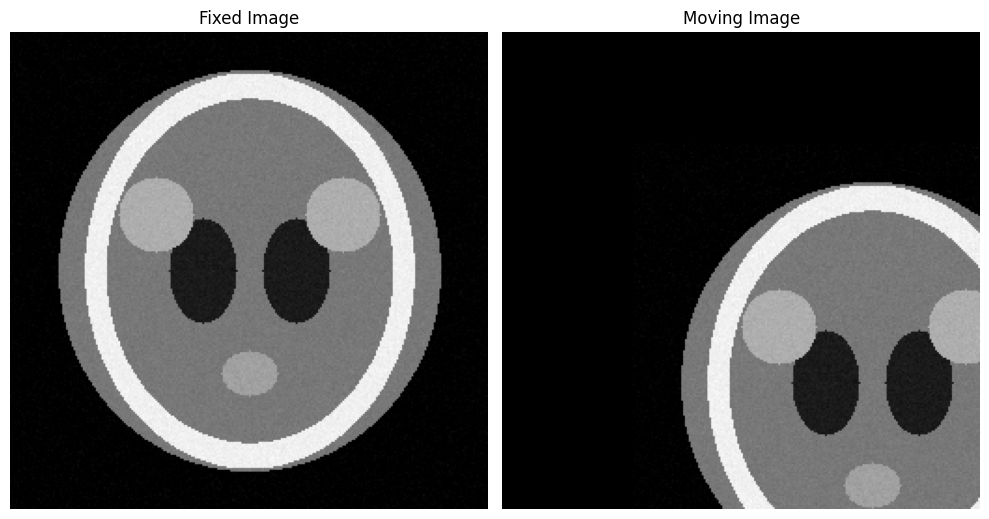

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.widgets import Button
import cv2
import os
import sys

def translate_image(img, tx, ty):
    rows, cols = img.shape
    shifted = np.zeros_like(img)

    for i in range(rows):
        for j in range(cols):
            new_i = i + tx
            new_j = j + ty
            if 0 <= new_i < rows and 0 <= new_j < cols:
                shifted[new_i, new_j] = img[i, j]

    return shifted






def create_synthetic_ct_brain(size=256, shift_x=30, shift_y=20, rotation_deg=15):
    """
    Creates a fake CT-like brain image with:
    - Oval skull
    - Brain tissue inside
    - Ventricles (dark regions)
    - White matter patches

    Returns:
        fixed  → reference image (no transformation)
        moving → shifted + rotated version (needs registration)
    """
    img = np.zeros((size, size), dtype=np.float32)
    cx, cy = size // 2, size // 2

    # --- Draw skull (bright ring) ---
    for y in range(size):
        for x in range(size):
            dist = ((x - cx) / 0.75) ** 2 + ((y - cy) / 0.9) ** 2
            skull_outer = (size * 0.46) ** 2
            skull_inner = (size * 0.40) ** 2
            if skull_inner < dist < skull_outer:
                img[y, x] = 0.9   # bright = bone

    # --- Draw brain tissue ---
    Y, X = np.ogrid[:size, :size]
    brain_mask = ((X - cx) / (size * 0.40)) ** 2 + ((Y - cy) / (size * 0.42)) ** 2 <= 1
    img[brain_mask] = np.where(img[brain_mask] > 0, img[brain_mask], 0.45)

    # --- Draw ventricles (dark CSF spaces) ---
    vent_left  = ((X - (cx - 25)) / 18) ** 2 + ((Y - cy) / 28) ** 2 <= 1
    vent_right = ((X - (cx + 25)) / 18) ** 2 + ((Y - cy) / 28) ** 2 <= 1
    img[vent_left]  = 0.1
    img[vent_right] = 0.1

    # --- Add white matter blobs ---
    wm1 = ((X - (cx - 50)) / 20) ** 2 + ((Y - (cy - 30)) / 20) ** 2 <= 1
    wm2 = ((X - (cx + 50)) / 20) ** 2 + ((Y - (cy - 30)) / 20) ** 2 <= 1
    wm3 = ((X - cx) / 15) ** 2       + ((Y - (cy + 55)) / 12) ** 2 <= 1
    img[wm1] = 0.65
    img[wm2] = 0.65
    img[wm3] = 0.6

    # Add slight noise for realism
    img += np.random.normal(0, 0.015, img.shape).astype(np.float32)
    img = np.clip(img, 0, 1)

    fixed_image = img.copy()

    # --- Create MOVING image by applying shift + rotation ---
    h, w = img.shape
    center = (w / 2, h / 2)

    # Build rotation + translation matrix
    # M = cv2.getRotationMatrix2D(center, rotation_deg, scale=1.0)
    # M[0, 2] += shift_x   # add x translation
    # M[1, 2] += shift_y   # add y translation

    # moving_image = cv2.warpAffine(
    #     img, M, (w, h),
    #     flags=cv2.INTER_LINEAR,
    #     borderMode=cv2.BORDER_CONSTANT,
    #     borderValue=0
    # )
    moving_image = translate_image(fixed_image, 60, 70)

    return fixed_image, moving_image  # M = ground truth transform

fixed, moving= create_synthetic_ct_brain(
            size=256, shift_x=30, shift_y=20, rotation_deg=15
        )

plt.figure(figsize=(10, 10))

# Fixed image
plt.subplot(1, 2, 1)
plt.imshow(fixed, cmap='gray')
plt.title("Fixed Image")
plt.axis('off')

# Moving image
plt.subplot(1, 2, 2)
plt.imshow(moving, cmap='gray')
plt.title("Moving Image")
plt.axis('off')

plt.tight_layout()
plt.show()

